Par : Pedro Gomes, Elie Hatoum, Thibault Lefay, Etienne Rousseau

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegresso
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [7]:
# On lit le CSV

In [8]:
df = pd.read_csv("marketing_and_sales.csv")


In [9]:
# On affiche les 5 premières lignes 

In [10]:
df.head()

,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181


In [11]:
#types des colonnes, valeurs null, nombre de lignes

In [12]:
# La on peu voir qu'il y a une 30ène de ligne avec des données null 

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social Media  4566 non-null   float64
 3   Influencer    4572 non-null   str    
 4   Sales         4566 non-null   float64
dtypes: float64(4), str(1)
memory usage: 178.7 KB


In [14]:
# moyenne, min, max, écart type

In [15]:
# Actuellement on constate pas forcément de données abérantes a premières vue

In [16]:
df.describe()

,TV,Radio,Social Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [17]:
# On supprime donc les données null

In [18]:
# Supprimer les lignes avec des valeurs manquantes et filtrer les budgets trop faibles
df = df.dropna().query("`Social Media` > 0.001 & Radio > 0.001")


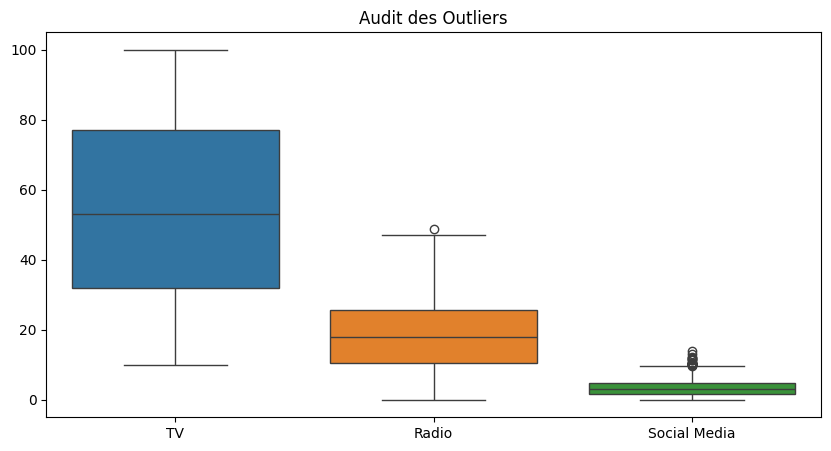

In [19]:
# Afficher des boîtes à moustaches pour voir les valeurs aberrantes de chaque budget
plt.figure(figsize=(10, 5)); sns.boxplot(data=df[['TV', 'Radio', 'Social Media']]); plt.title("Audit des Outliers"); plt.show()


In [20]:
#Ce sont des valeurs possibles mais rares. (les petits points)
#Exemple : Une énorme campagne de Noël où on a mis le paquet sur le Social Media. C'est très haut par rapport à la moyenne, mais c'est une vraie donnée.
#Action : On les garde ! Si on les supprimes, tle modèle ne saura jamais prédire ce qui se passe pour les grosses campagnes. 
#Il deviendrait "aveugle" face aux gros budgets.

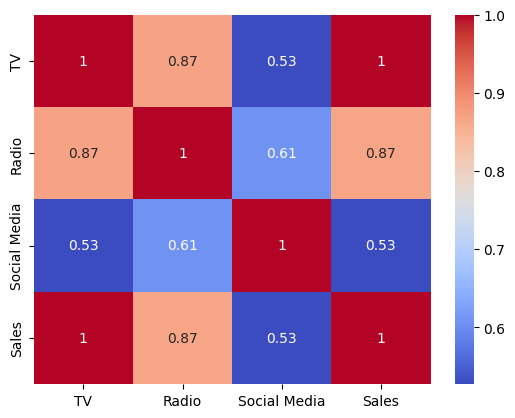

In [21]:
# Afficher la matrice de corrélation pour voir qui influence le plus les Sales
# On ajoute 'numeric_only=True' pour que Pandas ignore les colonnes de texte
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm'); plt.show()

# On constate très clairement que la TV influence le plus ventes

In [22]:
# On transforme le texte en colonnes de 0 et 1 (One-Hot Encoding)
df_final = pd.get_dummies(df, columns=['Influencer'], drop_first=True); df_final.head()

# On peu pas faire de maths sur des mots donc on transforme en True/False

,TV,Radio,Social Media,Sales,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,16.0,6.566231,2.907983,54.732757,True,False,False
1,13.0,9.237765,2.409567,46.677897,True,False,False
2,41.0,15.886446,2.913410,150.177829,True,False,False
3,83.0,30.020028,6.922304,298.246340,True,False,False
4,15.0,8.437408,1.405998,56.594181,False,True,False


In [23]:
# On sépare les données : X (les budgets) et y (les ventes), puis on divise en Train/Test
from sklearn.model_selection import train_test_split; X = df_final.drop('Sales', axis=1); y = df_final['Sales']; X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Le but de faire cette commande est tous simplement pour verifier que l'IA sorte des resulats (sans trichés)
# en gros, si on lui donnais tous il lui suffit de cracher les info sans reflechir que si on retire une parti et qu'on predit les 20 derniers pourcent
# grace au 80 pourcent et que sa donne les meme resultats que tous assemblé alors c'est bon.

In [24]:
# On crée le modèle, on l'entraîne sur le Train, et on affiche le score sur le Test
from sklearn.linear_model import LinearRegression; model_lr = LinearRegression(); model_lr.fit(X_train, y_train); print(f"Précision (R²) du modèle : {model_lr.score(X_test, y_test):.4f}")


Précision (R²) du modèle : 0.9990


In [25]:
#Un score de 0.9990 signifie que le modèle explique 99,9% de la variation des ventes. En gros, il ne se trompe quasiment jamais.

In [26]:
# On entraîne le Random Forest et on compare son score
from sklearn.ensemble import RandomForestRegressor; model_rf = RandomForestRegressor(n_estimators=100, random_state=42); model_rf.fit(X_train, y_train); print(f"Score R² Random Forest : {model_rf.score(X_test, y_test):.4f}")


Score R² Random Forest : 0.9988


In [27]:
# On entraîne un SVR (avec standardisation) et on compare son score
model_svr = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=10.0, epsilon=0.1))
model_svr.fit(X_train, y_train)
print(f"Score R² SVR : {model_svr.score(X_test, y_test):.4f}")

Score R² SVR : 0.9973


In [28]:
# La Régression Linéaire, c'est une règle : elle trace la ligne d'un coup, c'est parfait.
# Le Random Forest, c'est un escalier : il essaie de suivre la ligne en faisant plein de petites marches ("Si TV > 10, alors..."). 
# Sur une ligne droite, un escalier sera toujours un tout petit peu moins précis qu'une règle.
# Le SVR s'adapte a une courbe et ignore les petits ecarts.
# Il est utile si la relation n'est pas parfaitement lineaire.
# Conclusion : Pour ce projet, le modèle le plus simple, La Régression Linéaire est le meilleur !

In [29]:
# On calcule l'erreur moyenne pour la Régression Linéaire (notre championne)
from sklearn.metrics import mean_absolute_error; predictions = model_lr.predict(X_test); print(f"Erreur moyenne (MAE) : {mean_absolute_error(y_test, predictions):.2f} unités")


Erreur moyenne (MAE) : 2.28 unités
